# Predicting House Prices

## Problem Definition


State the business problem. Translate the business problem into a Data Science problem by stating what kind of problem it is ( supervised vs unsupervised ) and whether it is a classification, regression, or clustering problem.

We want to predict the sales prices of a home given a number of the property's features.

- there is a target
- supervised learning
- the target is SalePrice, which is numerical, continuous
- regression

This is a supervised, regression problem and we'll be using Linear Regression to make the predictions.  We'll also be using Ridge and Lasso regularization techniques to reduce overfitting and for feature selection.  Our performance metric with be RMSPE.


## Data Collection/Sources


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


### IDA


In [ ]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv"
url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'

In [ ]:
!curl -s -I {url} | grep -i -e ^http -e type: -e length:


HTTP/1.1 200 OK
Content-Type: text/csv
Content-Length: 880420


In [ ]:
!curl -s {url} | head -n 2


PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
905101070,20,RL,62.0,14299,Pave,,Reg,Lvl,AllPub,Inside,G

### Reading in the data

In [ ]:
df = pd.read_csv( url )
df


,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


In [ ]:
df.shape


(2637, 81)

In [ ]:
df.head()


,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


In [ ]:
df.tail()


,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000
2636,528292060,60,RL,41.0,12460,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,225000


#### Columns


In [ ]:
list(enumerate(df.columns.to_list(), start=100))


[(100, 'PID'),
 (101, 'MS SubClass'),
 (102, 'MS Zoning'),
 (103, 'Lot Frontage'),
 (104, 'Lot Area'),
 (105, 'Street'),
 (106, 'Alley'),
 (107, 'Lot Shape'),
 (108, 'Land Contour'),
 (109, 'Utilities'),
 (110, 'Lot Config'),
 (111, 'Land Slope'),
 (112, 'Neighborhood'),
 (113, 'Condition 1'),
 (114, 'Condition 2'),
 (115, 'Bldg Type'),
 (116, 'House Style'),
 (117, 'Overall Qual'),
 (118, 'Overall Cond'),
 (119, 'Year Built'),
 (120, 'Year Remod/Add'),
 (121, 'Roof Style'),
 (122, 'Roof Matl'),
 (123, 'Exterior 1st'),
 (124, 'Exterior 2nd'),
 (125, 'Mas Vnr Type'),
 (126, 'Mas Vnr Area'),
 (127, 'Exter Qual'),
 (128, 'Exter Cond'),
 (129, 'Foundation'),
 (130, 'Bsmt Qual'),
 (131, 'Bsmt Cond'),
 (132, 'Bsmt Exposure'),
 (133, 'BsmtFin Type 1'),
 (134, 'BsmtFin SF 1'),
 (135, 'BsmtFin Type 2'),
 (136, 'BsmtFin SF 2'),
 (137, 'Bsmt Unf SF'),
 (138, 'Total Bsmt SF'),
 (139, 'Heating'),
 (140, 'Heating QC'),
 (141, 'Central Air'),
 (142, 'Electrical'),
 (143, '1st Flr SF'),
 (144, '2nd Fl

In [ ]:
df.dtypes.value_counts()

,count
object,43
int64,27
float64,11


In [ ]:
pd.set_option('display.max_rows', 100)
df.dtypes.sort_values()


,0
PID,int64
Low Qual Fin SF,int64
Gr Liv Area,int64
Full Bath,int64
Half Bath,int64
Bedroom AbvGr,int64
Kitchen AbvGr,int64
TotRms AbvGrd,int64
Fireplaces,int64
Wood Deck SF,int64


### Examine target

In [ ]:
target = "SalePrice"
target


'SalePrice'

In [ ]:
df[target]

,SalePrice
0,115400
1,90000
2,141000
3,254000
4,155000
...,...
2632,114500
2633,162000
2634,211500
2635,165000


In [ ]:
df[target].isnull().sum()


np.int64(0)

In [ ]:
df[target].dtype


dtype('int64')

In [ ]:
df[ target ].min()

12789

### Examine features


#### Unique IDs

In [ ]:
(df.index.size-df.nunique()).sort_values().head()


,0
PID,0
Lot Area,838
Gr Liv Area,1421
Bsmt Unf SF,1557
1st Flr SF,1615


In [ ]:
cols_drop = ["PID"]
cols_drop

['PID']

### Categorical, likely


In [ ]:
filter = df.nunique() < 20
df.nunique()[ filter ].sort_values(ascending = False)


,0
Exterior 2nd,17
Exterior 1st,16
MS SubClass,16
Mo Sold,12
TotRms AbvGrd,12
Pool Area,12
Sale Type,10
Overall Qual,10
Condition 1,9
Overall Cond,9


#### Floats


In [ ]:
float_df = df.select_dtypes(include = 'float')
float_df


,Lot Frontage,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Bsmt Full Bath,Bsmt Half Bath,Garage Yr Blt,Garage Cars,Garage Area
0,62.0,0.0,513.0,144.0,348.0,1005.0,1.0,0.0,1964.0,2.0,440.0
1,72.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1967.0,2.0,516.0
2,50.0,0.0,0.0,0.0,780.0,780.0,0.0,0.0,1979.0,1.0,544.0
3,68.0,0.0,484.0,0.0,491.0,975.0,1.0,0.0,2000.0,2.0,592.0
4,60.0,0.0,350.0,210.0,0.0,560.0,1.0,0.0,1971.0,2.0,576.0
...,...,...,...,...,...,...,...,...,...,...,...
2632,52.0,0.0,0.0,0.0,816.0,816.0,0.0,0.0,1985.0,2.0,528.0
2633,74.0,0.0,460.0,286.0,308.0,1054.0,1.0,0.0,1990.0,2.0,462.0
2634,61.0,0.0,960.0,0.0,266.0,1226.0,1.0,0.0,1981.0,2.0,484.0
2635,78.0,174.0,0.0,0.0,1064.0,1064.0,0.0,0.0,1974.0,2.0,478.0


In [ ]:
float_df.isnull().sum().sort_values(ascending = False)


,0
Lot Frontage,449
Garage Yr Blt,147
Mas Vnr Area,23
Bsmt Half Bath,2
Bsmt Full Bath,2
BsmtFin SF 1,1
BsmtFin SF 2,1
Total Bsmt SF,1
Bsmt Unf SF,1
Garage Cars,1


#### Ints


In [ ]:
int_df = df.select_dtypes(include = 'int')
int_df


,PID,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,905101070,20,14299,4,3,1964,1964,1005,0,0,...,0,0,0,0,0,0,0,7,2007,115400
1,905101330,90,10791,4,5,1967,1967,1296,0,0,...,0,0,0,0,0,0,500,10,2006,90000
2,903454090,50,9000,6,6,1937,1950,780,595,0,...,0,162,0,0,126,0,0,12,2007,141000
3,533244030,60,7379,8,5,2000,2000,975,873,0,...,280,184,0,0,0,0,0,4,2010,254000
4,909252020,70,7200,7,9,1936,2007,575,560,0,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,6240,6,6,1934,1950,816,0,360,...,112,0,0,0,0,0,400,9,2006,114500
2633,906201021,80,10778,7,6,1990,1991,1061,0,0,...,114,36,0,0,0,0,0,7,2009,162000
2634,533253070,120,3782,8,5,1981,1981,1226,0,0,...,133,78,0,0,0,0,0,9,2009,211500
2635,527376100,20,10140,6,5,1974,1974,1350,0,0,...,0,0,0,0,0,0,0,8,2009,165000


In [ ]:
int_df.isnull().sum().sort_values(ascending = False)


,0
PID,0
MS SubClass,0
Lot Area,0
Overall Qual,0
Overall Cond,0
Year Built,0
Year Remod/Add,0
1st Flr SF,0
2nd Flr SF,0
Low Qual Fin SF,0


In [ ]:
int_df.nunique().sort_values()


,0
Half Bath,3
Kitchen AbvGr,4
Full Bath,5
Fireplaces,5
Yr Sold,5
Bedroom AbvGr,7
Overall Cond,9
Overall Qual,10
Pool Area,12
Mo Sold,12


#### Objects


In [ ]:
obj_df = df.select_dtypes(include = 'object')
obj_df


,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Feedr,...,Detchd,Unf,TA,TA,N,NaN,MnPrv,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,...,CarPort,Unf,TA,TA,Y,NaN,NaN,Shed,WD,Normal
2,RM,Pave,NaN,Reg,Bnk,AllPub,Inside,Gtl,IDOTRR,Norm,...,Detchd,Unf,TA,TA,P,NaN,NaN,NaN,WD,Normal
3,FV,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
4,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Feedr,...,Detchd,RFn,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,RM,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,...,Detchd,Unf,TA,TA,Y,NaN,MnPrv,Shed,WD,Normal
2633,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,SawyerW,Feedr,...,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2634,RL,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Greens,Norm,...,Attchd,Fin,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2635,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Attchd,RFn,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal


In [ ]:
obj_df.isnull().sum().sort_values(ascending = False)


,0
Pool QC,2626
Misc Feature,2541
Alley,2457
Fence,2109
Mas Vnr Type,1607
Fireplace Qu,1284
Garage Cond,147
Garage Qual,147
Garage Finish,147
Garage Type,145


### Select features



One feature

Numerical. No nulls. Lots of unique values.


In [ ]:
features = ["Lot Area"]
features


['Lot Area']

### Target + Features


In [ ]:
cols = [target] + features
cols


['SalePrice', 'Lot Area']

## Data Cleaning


## Exploratory Data Analysis


In [ ]:
eda_df = df[ cols ].copy()
eda_df


,SalePrice,Lot Area
0,115400,14299
1,90000,10791
2,141000,9000
3,254000,7379
4,155000,7200
...,...,...
2632,114500,6240
2633,162000,10778
2634,211500,3782
2635,165000,10140


### Correlation Matrix


In [ ]:
correlation_matrix = eda_df.corr().abs().round(2)
correlation_matrix


,SalePrice,Lot Area
SalePrice,1.00,0.27
Lot Area,0.27,1.00


In [ ]:
ones = np.ones_like( correlation_matrix, dtype = bool, )
mask = np.tril( ones, k = -1 )
lower_triangle_corr = correlation_matrix.where(mask)
lower_triangle_corr

,SalePrice,Lot Area
SalePrice,NaN,NaN
Lot Area,0.27,NaN


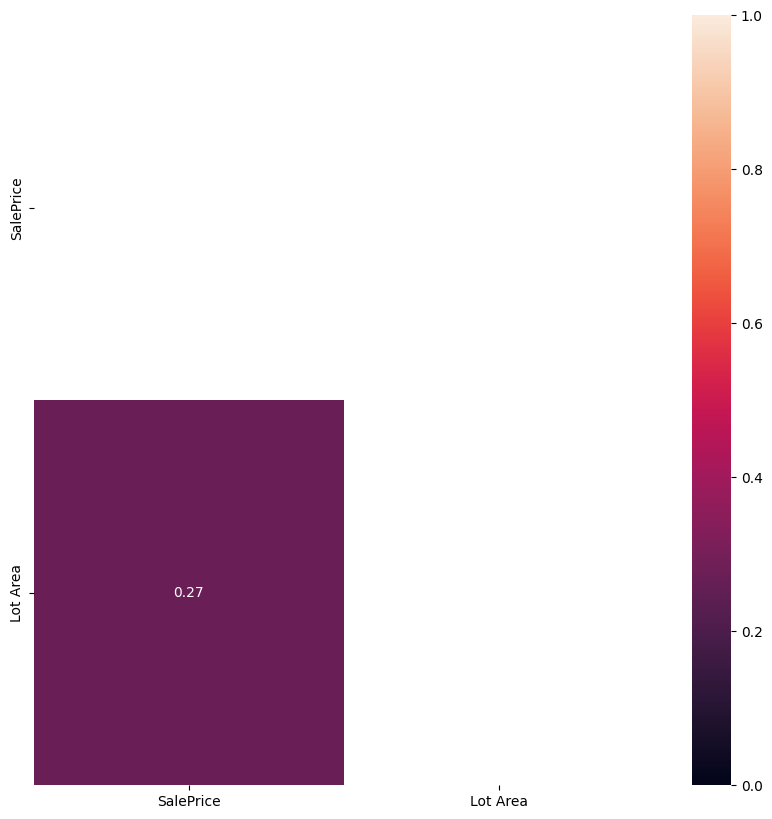

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(
    data=lower_triangle_corr,
    annot=True,
    vmin=0,
    vmax=1,
) ;

#### Target



In [ ]:
lower_triangle_corr[ target ].dropna().sort_values( ascending = False )

,SalePrice
Lot Area,0.27


#### Features



In [ ]:
(
lower_triangle_corr
  .drop( columns = [ target ] )
  .unstack()
  .dropna()
  .to_frame()
  .rename( columns={0:"r"} )
  # .query( "r > 0.90")
  # .sort_values( by = "r", ascending=False )
  # .reset_index()
)

,,r


### Box plot



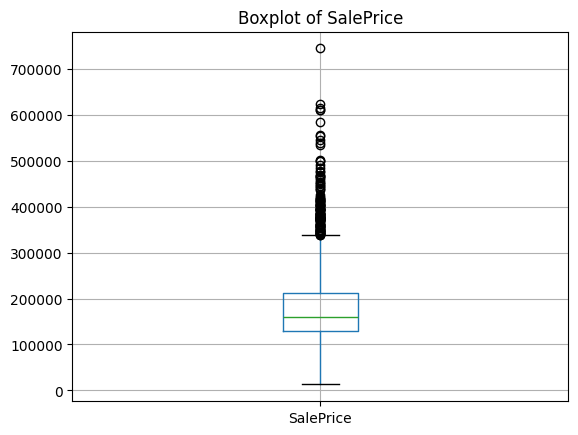

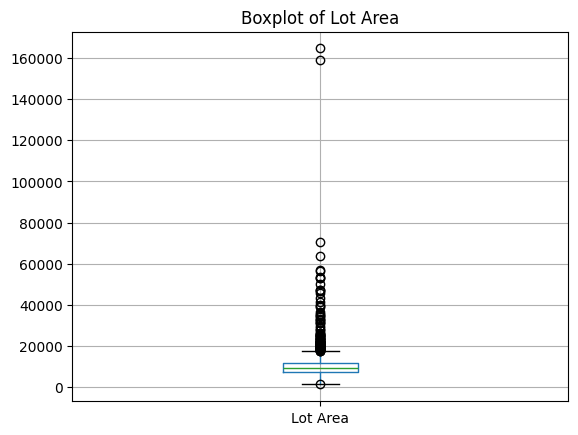

In [ ]:
for col in eda_df.columns:
    plt.figure()  # Creates a new, clean figure window
    eda_df.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.show()


### Histogram


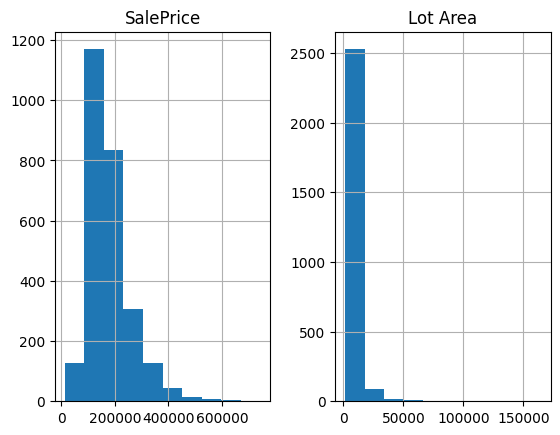

In [ ]:
eda_df.hist() ;


## Processing



#### Linear Regression


In [ ]:
# %%capture --no-stdout
X = eda_df.drop( target, axis = 1)
y = eda_df[ target ]
X.shape, y.shape


((2637, 1), (2637,))

In [ ]:
def rmspe( y_actual, y_pred):
  '''Calculates RMSPE given the known and predicted target values'''
  return (((y_actual - y_pred) / y_actual) **2).mean()**(1/2) * 100


In [ ]:
# Calculate CV RMSE
n = 500
results = np.zeros(n)

for idx in range(n):
  # Train, test split
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

  # Standard scale only training features
  scaler = StandardScaler()
  scaler.fit(X_train)
  X_train = scaler.transform(X_train)

  # Scale testing features
  X_test = scaler.transform(X_test)

  # Create the model
  my_fit = LinearRegression()

  # Fit regression
  my_fit.fit(X_train, y_train)

  # Predict
  y_pred = my_fit.predict(X_test)

  # Calculate and record performance metric
  results[idx] = rmspe(y_test,y_pred)

results.mean()


np.float64(60.65254165418245)

## Data Visualization/Communication of Results


#### RMSPE histogram

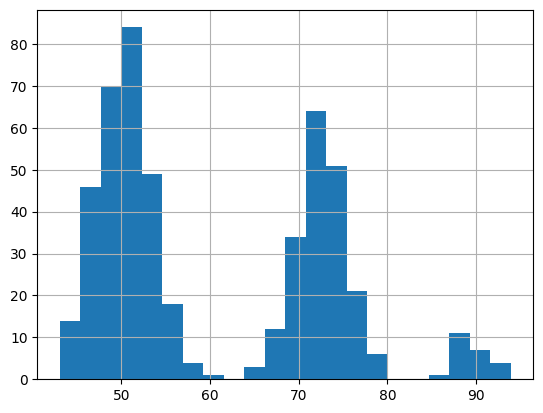

In [ ]:
results_ds = pd.Series(results)
results_ds.hist( bins = int(results_ds.size ** 0.5)) ;


### QQplot of residuals


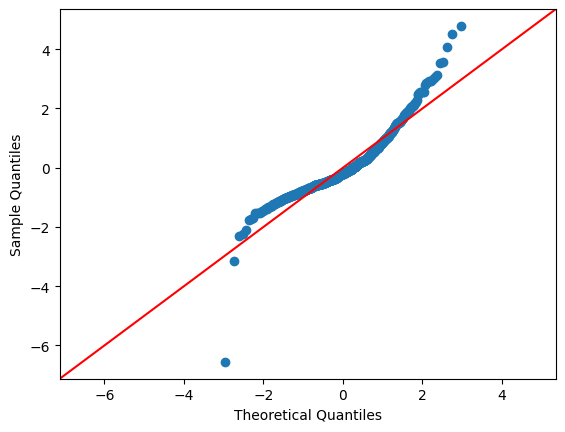

In [ ]:
res = y_test - y_pred
sm.qqplot(res, fit=True, line="45") ;


### Constant variance - Residuals vs Predicted


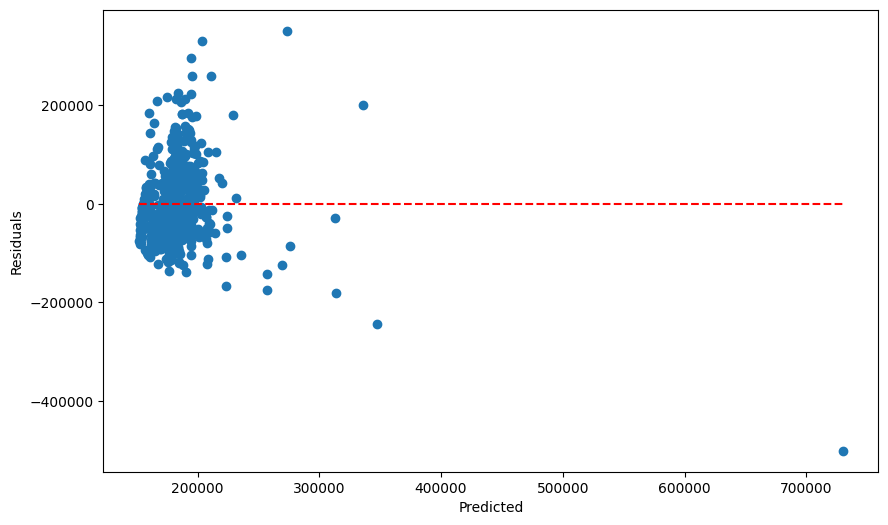

In [ ]:
plt.figure(figsize = (10,6))
plt.scatter(y_pred, res)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.hlines(0, min(y_pred), max(y_pred), colors = 'red', linestyles = 'dashed') ;


## Conclusion and Future work
- Conclusions
  - not a very good model with 60%+ error
  - the results histogram suggests 3 distinct populations
  -

- Future work
  - include more numerical features
  -